# **Дз1**

Создан счёт №ACC-1000 на сумму: 1500.0

=== Выполнение операций ===
Пополнение: +500
Снятие: -200
Попытка снятия 3700: Недостаточно средств
Пополнение: +1800

Текущий баланс: 3600.00

=== История операций ===
1. 08.11.2025 00:27:04 - DEPOSIT   1500.00 - success - Баланс:  1500.00 - Initial deposit
2. 08.11.2025 00:27:06 - DEPOSIT    500.00 - success - Баланс:  2000.00 - 
3. 08.11.2025 00:27:08 - WITHDRAW   200.00 - success - Баланс:  1800.00 - 
4. 08.11.2025 00:27:10 - WITHDRAW  3700.00 - fail    - Баланс:  1800.00 - Insufficient funds
5. 08.11.2025 00:27:12 - DEPOSIT   1800.00 - success - Баланс:  3600.00 - 

=== Визуализация истории операций ===


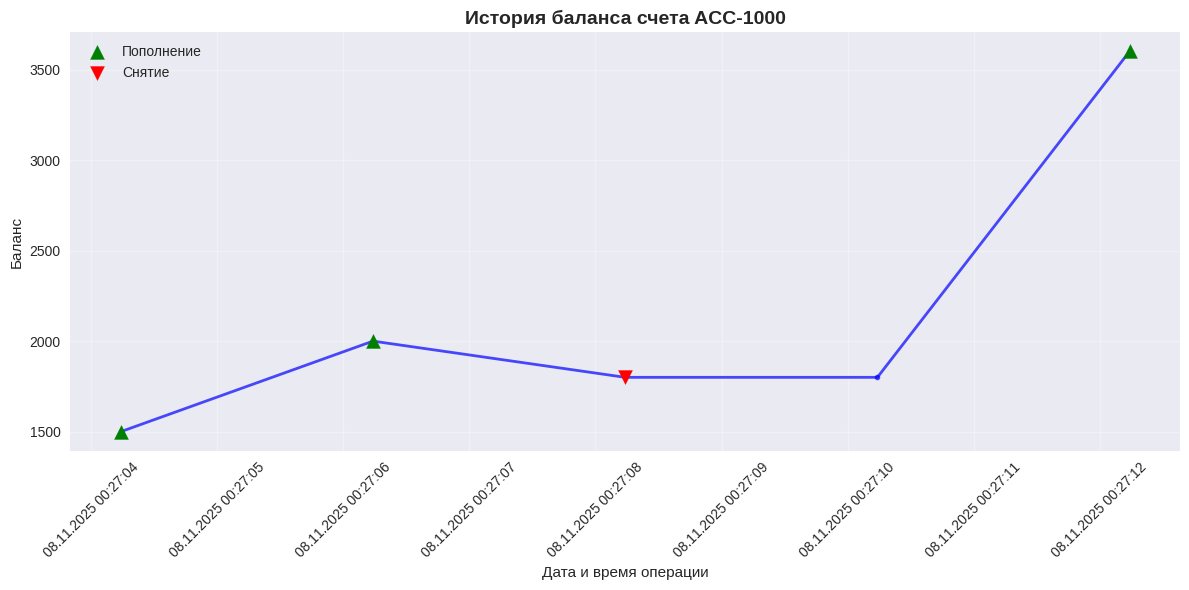

In [204]:
from datetime import datetime
from typing import List, Dict, Optional
import pandas as pd
import matplotlib.pyplot as plt
import time
import re
import json
import csv

class Account():
    _account_counter = 1000

    # Инициализация класса. Изменил сигнатуру для задания №3
    def __init__(self, account_holder: str, balance: float = 0.0,
                 account_number: str = None):

        # Исключение на отрицательный баланс
        self._validate_positive_amount(balance)

        # Исключение на формат имени владльца Счёта
        self._validate_account_holder(account_holder)

        self.holder = account_holder

        # Ручной ввод номера для задания №3
        if account_number:
            self.account_number = account_number
        else:
            self.account_number = self._generate_account_number()

        self._balance = float(balance)
        self.operations_history: List[Dict] = []

        # Операция депозита в случае, если баланс инициализируется не нулевым
        if balance > 0:
            self._record_operation('deposit', balance, 'success',
                                   "Initial deposit")

        print(f"Создан счёт №{self.account_number} на сумму: {self._balance}")

    # Генерации различных номеров счетов
    def _generate_account_number(self) -> str:
        account_num = Account._account_counter
        Account._account_counter += 1
        return f"ACC-{account_num}"

    # Запись операций по счёту в виде списка
    def _record_operation(self, operation_type: str, amount: float,
                         status: str, description: str = "") -> None:
        operation = {
            'type': operation_type,
            'amount': amount,
            'date_time': datetime.now(),
            'balance_after': self._balance,
            'status': status,
            'description': description
        }
        self.operations_history.append(operation)

    # Валидация имени владельца счёта
    def _validate_account_holder(self, account_holder: str) -> None:

        # Паттерн для формата "Имя Фамилия"
        pattern = r'^[A-ZА-ЯЁ][a-zа-яё]+\s[A-ZА-ЯЁ][a-zа-яё]+$'

        if not re.match(pattern, account_holder):
            raise ValueError(
                "Имя владельца должно быть в формате 'Имя Фамилия'"
                "с заглавных букв, кириллицей или латиницей.\n")

    # Валидация суммы в операциях
    def _validate_positive_amount(self, amount: float,
                                  field_name: str = "Сумма") -> None:
        if amount < 0:
            raise ValueError(f"{field_name} не может быть отрицательной")

    # Операция депозита
    def deposit(self, amount: float) -> None:

        # Исключение при отрицательном депозите
        self._validate_positive_amount(amount)

        self._balance += amount
        self._record_operation('deposit', amount, 'success')

        print(f"Пополнение: +{amount}")

    # Операция снятия
    def withdraw(self, amount: float) -> None:

        # Исключения при отрицательном снятии
        self._validate_positive_amount(amount)

        # Запись неудачного снятия средств в историю
        if amount > self._balance:
            self._record_operation('withdraw', amount, 'fail',
                                   "Insufficient funds")
            print(f"Попытка снятия {amount}: "
            f"{'Успешно' if result else 'Недостаточно средств'}")
        else:
            self._balance -= amount
            self._record_operation('withdraw', amount, 'success')

            print(f"Снятие: -{amount}")

    # Вывод текущего баланса
    def get_balance(self) -> float:
        return self._balance

    # Вывод истории операций по счёту
    def get_history(self, operations = False) -> List[Dict]:

        # Вывел список операций в качестве аргумента для реализации вывода по
        # убыванию суммы
        if not operations:
            operations = self.operations_history

        # Вывод истории в формате:
        # Дата - Операция - Статус - Баланс - Комментарии
        for i, op in enumerate(operations, 1):
            print(f"{i}. {op['date_time'].strftime('%d.%m.%Y %H:%M:%S')} - "
            f"{op['type'].upper():8} {op['amount']:8.2f} - "
            f"{op['status']:7} - Баланс: {op['balance_after']:8.2f} - "
            f"{op.get('description', '')}")

    # Вывод самых крупных транзакций, согласно 5 пункту 4 этапа
    def major_transactions(self, count):

        # Сортировка по убыванию суммы, после чего по убыванию дать
        operations = self.operations_history.copy()
        operations.sort(key=lambda x: (x['amount'],
                                       x['date_time']), reverse=True)
        operations = operations[:count]

        self.get_history(operations)

    # Визуализация графика
    def plot_history(self) -> None:

        # Создание датафрейма из истории операций
        df = pd.DataFrame(self.operations_history)

        # Привожу даты к типу datetime для дальнейшего вывода значений по оси Х
        df['date_time'] = pd.to_datetime(df['date_time'])
        df = df.sort_values('date_time')

        plt.style.use('seaborn-v0_8')
        fig, ax = plt.subplots(figsize=(12, 6))

        ax.plot(df['date_time'], df['balance_after'], marker='o', linewidth=2,
                markersize=4, color='blue', alpha=0.7)
        ax.set_title(f'История баланса счета {self.account_number}',
                        fontsize=14, fontweight='bold')
        ax.set_xlabel('Дата и время операции')
        ax.set_ylabel('Баланс')
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)

        # Формат дат для выводы
        date_format = plt.matplotlib.dates.DateFormatter('%d.%m.%Y %H:%M:%S')
        ax.xaxis.set_major_formatter(date_format)
        ax.xaxis.set_major_locator(plt.matplotlib.dates.AutoDateLocator())

        # Выделение момента операций
        success_ops = df[df['status'] == 'success']
        for _, op in success_ops.iterrows():
            color = 'green' if op['type'] == 'deposit' else 'red'
            marker = '^' if op['type'] == 'deposit' else 'v'
            label = 'Пополнение' if op['type'] == 'deposit' else 'Снятие'
            ax.scatter(op['date_time'], op['balance_after'], color=color,
                       marker=marker, s=100, zorder=5, label=label)

        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys())

        plt.tight_layout()
        plt.show()

    # Загрузка транзакций из файла
    def load_history_from_file(self, file_path):
        transactions = self._read_transactions(file_path)
        cleaned_transactions = self.clean_history(transactions)

        self._apply_transactions(cleaned_transactions)

    # Чтение транзакций (json, csv)
    def _read_transactions(self, file_path):
        transactions = []

        if file_path.endswith('.json'):
            with open(file_path, 'r', encoding='utf-8') as file:
                transactions = json.load(file)
        elif file_path.endswith('.csv'):
            with open(file_path, 'r', encoding='utf-8') as file:
                reader = csv.DictReader(file)
                transactions = list(reader)

        # Преобразование строк в числа
        for transaction in transactions:
            if transaction.get('amount'):
                transaction['amount'] = float(transaction['amount'])
            if transaction.get('balance_after'):
                transaction['balance_after'] = float(
                    transaction['balance_after'])

        return transactions

    # Очистка истории транзакций от ошибок
    def clean_history(self, transactions):
        cleaned_transactions = []

        for transaction in transactions:
            if self._is_valid_transaction(transaction):
                cleaned_transactions.append(transaction)

        return cleaned_transactions

    # Проверка валидности транзакций
    def _is_valid_transaction(self, transaction):
        # Проверка номера аккаунта
        if transaction.get('account_number') != self.account_number:
            return False

        # Проверка типа аккаунта
        if transaction.get('account_type') != self.account_type:
            return False

        # Проверка типа операции
        operation = transaction.get('operation')
        if not operation or operation not in self.get_allowed_operations():
            return False

        # Проверка суммы
        amount = transaction.get('amount')

        # Проверка, что в сумме - число
        if isinstance(amount, str):
            try:
                amount = float(amount)
            except (ValueError, TypeError):
                return False

        if amount is None or amount <= 0:
            return False

        # Проверка даты
        if not self._is_valid_date(transaction.get('date')):
            return False

        # Проверка статуса
        if transaction.get('status') != 'success':
            return False

        return True

    # Проверка валидности даты
    def _is_valid_date(self, date_str):
        if not date_str:
            return False

        # Разные форматы даты
        date_formats = [
            '%Y-%m-%d %H:%M:%S',
            '%d/%m/%Y %H:%M',
            '%Y-%m-%d %H:%M',
            '%d/%m/%Y %H:%M:%S'
        ]

        for date_format in date_formats:
            try:
                datetime.strptime(date_str, date_format)
                return True
            except ValueError:
                continue

        return False

    # Обновление счёта после чтения файла
    def _apply_transactions(self, transactions):
        for transaction in transactions:
            operation = transaction['operation']
            amount = transaction['amount']

            if operation == 'deposit':
                self._balance += amount
            elif operation == 'withdraw':
                self._balance -= amount
            elif operation == 'interest':
                self._balance += amount

            # Привожу дату к типу datetime для корректного вывода
            parsed_date = self._parse_date_string(transaction['date'])

            # Добавление транзакции в историю
            self.operations_history.append({
                'type': operation,
                'amount': amount,
                'date_time': parsed_date,
                'balance_after': transaction['balance_after'],
                'status': transaction['status'],
                'description': ''
            })

    # Привожу строку даты к корректному типу
    def _parse_date_string(self, date_str):
        date_formats = [
        '%Y-%m-%d %H:%M:%S',
        '%d/%m/%Y %H:%M',
        '%Y-%m-%d %H:%M',
        '%d/%m/%Y %H:%M:%S'
        ]

        for date_format in date_formats:
            try:
                return datetime.strptime(date_str, date_format)
            except ValueError:
                continue

    # Метод проверки типа операции. Реализация на дочерних классах
    # Не сделал данный метод абстрактным, поскольку Colab не видет реализацию
    # метода в другом блоке
    def get_allowed_operations(self):
        pass


# Создание счёта
account1 = Account("Денис Вальчук", 1500)

# Операции со счетом
print("\n=== Выполнение операций ===")

# Добавил ожидания, чтобы на графике были различные значения по оси Х
time.sleep(2)
account1.deposit(500)

time.sleep(2)
account1.withdraw(200)

time.sleep(2)
result = account1.withdraw(3700)

time.sleep(2)
account1.deposit(1800)

print(f"\nТекущий баланс: {account1.get_balance():.2f}")

# История операций
print("\n=== История операций ===")
account1.get_history()

# Визуализация
print("\n=== Визуализация истории операций ===")
account1.plot_history()

# **Дз2**

In [205]:
class CheckingAccount(Account):

    # Иннициализация класса
    def __init__(self, account_holder: str, balance: float = 0.0,
                 account_number: str = None):

        # Наследование атрибутов базового класса
        super().__init__(account_holder, balance, account_number)

        # Тип класса
        self.account_type = "checking"

    # Доступные операции для импорта из файла
    def get_allowed_operations(self):
        return ['deposit', 'withdraw']

class SavingsAccount(Account):

    # Иннициализация класса
    def __init__(self, account_holder: str, balance: float = 0.0,
                 account_number: str = None):

        # Наследование атрибутов базового класса
        super().__init__(account_holder, balance, account_number)

        # Тип класса
        self.account_type = "savings"

    # Расчёт процентов на остаток
    def apply_interest(self, rate: float) -> bool:

        # Исключение на случай отрицательного процента
        if rate <= 0:
            raise ValueError("Процентная ставка должна быть положительной")

        interest = self._balance * (rate / 100)
        self._balance += interest

        return True

    # Модификация метода снятия средств
    def withdraw(self, amount: float) -> None:

        # Реализация блокирования вывода более 50% средств
        max_withdrawal = self._balance * 0.5
        if amount > max_withdrawal:
            self._record_operation('withdraw', amount, 'fail',
                                 f"Exceeds 50% limit. Max withdrawal: "
                                 f"{max_withdrawal:.2f}")
            print(f"Попытка снять {amount}: 'Неудачно' (ограничение 50%)")
            return None

        # Вызов родительского метода во избежания повторения кода
        return super().withdraw(amount)

    # Доступные операции для импорта из файла
    def get_allowed_operations(self):
        return ['deposit', 'withdraw', 'interest']


# Тестирование CheckingAccount
print("\n=== Тестирование CheckingAccount ===")
checking = CheckingAccount("Анна Тестик", 1000)

checking.deposit(500)
checking.withdraw(200)
checking.withdraw(800)

print(f"Баланс расчетного счета: {checking.get_balance():.2f}")

# Тестирование SavingsAccount
print("\n=== Тестирование SavingsAccount ===")
savings = SavingsAccount("Надежда Случайная", 1000)

savings.deposit(500)
print(f"После пополнения: {savings.get_balance():.2f}")

# Попытка снять больше 50%
result = savings.withdraw(800)

# Успешное снятие в пределах лимита
result = savings.withdraw(600)
print(f"После снятия: {savings.get_balance():.2f}")

# Начисление процентов
savings.apply_interest(5.0)
print(f"После начисления 5%: {savings.get_balance():.2f}")


=== Тестирование CheckingAccount ===
Создан счёт №ACC-1001 на сумму: 1000.0
Пополнение: +500
Снятие: -200
Снятие: -800
Баланс расчетного счета: 500.00

=== Тестирование SavingsAccount ===
Создан счёт №ACC-1002 на сумму: 1000.0
Пополнение: +500
После пополнения: 1500.00
Попытка снять 800: 'Неудачно' (ограничение 50%)
Снятие: -600
После снятия: 900.00
После начисления 5%: 945.00


**Проверка валидации имени владельца счёта**

In [206]:
# Кейс №1. Правильный формат на кириллице
test = Account("Денис Вальчук", 1500)
print(f"Владелец: {test.holder}")

Создан счёт №ACC-1003 на сумму: 1500.0
Владелец: Денис Вальчук


In [207]:
# Кейс №2. Правильный формат на латинице
test = Account("Denis Valchuk", 1500)
print(f"Владелец: {test.holder}")

Создан счёт №ACC-1004 на сумму: 1500.0
Владелец: Denis Valchuk


In [208]:
# Кейс №3. Неправильный формат на кириллице
test = Account("денис Вальчук", 1500)
print(f"Владелец: {test.holder}")

ValueError: Имя владельца должно быть в формате 'Имя Фамилия'с заглавных букв, кириллицей или латиницей.


In [209]:
# Кейс №4. Неправильный формат на латинице
test = Account("denis Valchuk", 1500)
print(f"Владелец: {test.account_holder}")

ValueError: Имя владельца должно быть в формате 'Имя Фамилия'с заглавных букв, кириллицей или латиницей.


**Проверка валидации сумм операций по счёту**

In [210]:
# Кейс №1. Создание счёта с отрицательным балансом
test = Account("Денис Вальчук", -1500)

ValueError: Сумма не может быть отрицательной

In [211]:
# Кейс №2. Отрицательный депозит
account1.deposit(-500)

ValueError: Сумма не может быть отрицательной

In [212]:
# Кейс №3. Отрицательное снятие
account1.withdraw(-500)

ValueError: Сумма не может быть отрицательной

**Вывод заданного количества крупных транзакций в порядке убыванию по сумме, дате**

In [213]:
# Метод ориентируется в первую очередь на сумму операции, после на дату
print(account1.major_transactions(3))

1. 08.11.2025 00:27:10 - WITHDRAW  3700.00 - fail    - Баланс:  1800.00 - Insufficient funds
2. 08.11.2025 00:27:12 - DEPOSIT   1800.00 - success - Баланс:  3600.00 - 
3. 08.11.2025 00:27:04 - DEPOSIT   1500.00 - success - Баланс:  1500.00 - Initial deposit
None


# Дз 3

In [214]:
# Реализация json для cберигательного счёта
saving_acc = SavingsAccount("Артур Джейсонович", 1200, 'ACC-100002')

saving_acc.load_history_from_file("/content/transactions_dirty.json")
print(f'Сумма после загрузки: {saving_acc.get_balance():8.2f}')

Создан счёт №ACC-100002 на сумму: 1200.0
Сумма после загрузки:  4329.24


In [215]:
# Реализация csv для cберигательного счёта
saving_acc = SavingsAccount("Артур Сиэсвишич", 1200, 'ACC-100004')

saving_acc.load_history_from_file("/content/transactions_dirty.csv")
print(f'Сумма после загрузки: {saving_acc.get_balance():8.2f}')

Создан счёт №ACC-100004 на сумму: 1200.0
Сумма после загрузки:  8948.25


In [216]:
# Реализация json для расчётного счёта
checking_acc = CheckingAccount("Мария Джейсонович", 1200, 'ACC-100001')

checking_acc.load_history_from_file("/content/transactions_dirty.json")
print(f'Сумма после загрузки: {checking_acc.get_balance():8.2f}')

Создан счёт №ACC-100001 на сумму: 1200.0
Сумма после загрузки:  4471.00


In [217]:
# Реализация csv для расчётного счёта
checking_acc = CheckingAccount("Мария Сиэсвишич", 1200, 'ACC-100003')

checking_acc.load_history_from_file("/content/transactions_dirty.csv")
print(f'Сумма после загрузки: {checking_acc.get_balance():8.2f}')

Создан счёт №ACC-100003 на сумму: 1200.0
Сумма после загрузки:  5846.00
